In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
data=pd.read_csv(r"C:\Users\ashis\OneDrive\Documents\Internship\Code Alpha Interndhip\ML Projects\Disease Prediction\Diabetes Prediction\diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
data.shape

(768, 9)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
X=data.drop(["Outcome"], axis=1)
y=data["Outcome"]

In [9]:
scaler = StandardScaler()
X=scaler.fit_transform(X)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [13]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train, y_train)

SVC()

In [15]:
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier(n_estimators=100)
rfc.fit(X_train, y_train)

RandomForestClassifier()

In [16]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
dtc.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)

In [17]:
from xgboost import XGBClassifier
xgb=XGBClassifier(
    n_estimators=100,learning_rate=0.1, max_depth=5, use_label_encoder=False, eval_metric='logloss', random_state=42
)
xgb.fit(X_train, y_train)

C:\Users\ashis\miniconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:11:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [18]:
models={
    "Logistic Regression":lr,
    "SVM":svm,
    "Random Forest":rfc,
    "Decision Tree":dtc,
    "XGBoost":xgb
}

In [19]:
from sklearn.metrics import accuracy_score, classification_report

In [24]:
results=[]

for name,model in models.items():
    prediction=model.predict(X_test)
    accuracy=accuracy_score(y_test, prediction)
    results.append({
        "Model":name,
        "Accuracy":accuracy
    })

results_df=pd.DataFrame(results)
print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.753247
1                  SVM  0.727273
2        Random Forest  0.746753
3        Decision Tree  0.792208
4              XGBoost  0.720779


In [26]:
for name,model in models.items():
    pred=model.predict(X_test)
    report=classification_report(y_test, pred)
    print("Model:", name)
    print("Classification Report:\n", report)
    print("-"*50)

Model: Logistic Regression
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154

--------------------------------------------------
Model: SVM
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.82      0.79        99
           1       0.63      0.56      0.60        55

    accuracy                           0.73       154
   macro avg       0.70      0.69      0.70       154
weighted avg       0.72      0.73      0.72       154

--------------------------------------------------
Model: Random Forest
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.80      0.80        99
    

In [27]:
from sklearn.metrics import confusion_matrix

In [29]:
y_pred=xgb.predict(X_test)
cm=confusion_matrix(y_test, y_pred)

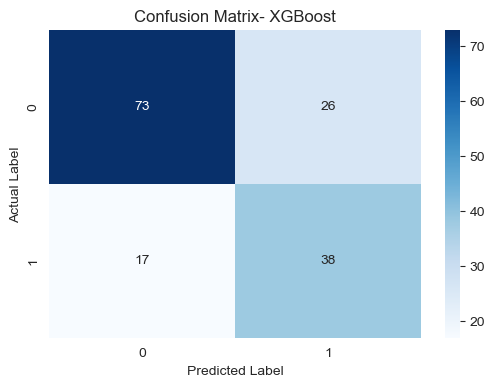

In [32]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix- XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [33]:
from sklearn.metrics import roc_curve, roc_auc_score

In [42]:
models = {
    "Logistic Regression": lr,
    "Random Forest": rfc,
    "Decision Tree": dtc,
    "XGBoost": xgb
}

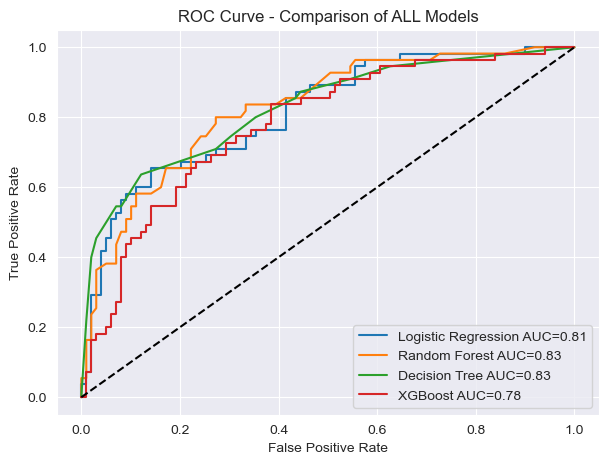

In [44]:
plt.figure(figsize=(7,5))
for name, model in models.items():
    y_proba=model.predict_proba(X_test)[:,1]
    fpr, tpr, _ =roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr,tpr, label=f"{name} AUC={auc_score:.2f}")

plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Comparison of ALL Models')
plt.legend()
plt.show()

In [45]:
from sklearn.pipeline import Pipeline

In [46]:
xgb_model=XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=4, eval_metruc='logloss', random_state=42
)

In [47]:
pipeline=Pipeline(steps=[("scaler", StandardScaler()), ("model", xgb_model)])

In [48]:
pipeline.fit(X_train, y_train)

C:\Users\ashis\miniconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:10:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "eval_metruc" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               eval_metruc='logloss', feature_types=None,
                               feature_weights=None, gamma=None,
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None, ...))])

In [50]:
import joblib

In [51]:
joblib.dump(pipeline, "diabetes_xgboost_pipeline.joblib")

['diabetes_xgboost_pipeline.joblib']